# Đánh giá Thuật toán Di truyền (GA) cho Xếp Lịch Thi

Notebook này thực hiện đánh giá toàn diện các phương pháp fitness khác nhau
của thuật toán di truyền để tìm lịch thi tối ưu.

## Các phương pháp được đánh giá:
1. **Weighted Fitness** - Tổ hợp có trọng số của hard và soft constraints
2. **Alpha-Beta Fitness** - Điểm số alpha-beta cho hard và soft constraints
3. **Penalty Fitness** - Điểm trừ cho vi phạm hard, cộng cho soft
4. **Lexicographic Fitness** - Tối thiểu hóa vi phạm hard trước, sau đó tối đa hóa soft

In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import dataclasses
from typing import Dict, Any, List, Optional
from dataclasses import dataclass, field

sys.path.append(os.path.dirname(os.getcwd()))

from app import data_store
from app.schemas.schedule_request import ScheduleRequest
from app.ga.scheduler import GAScheduler
from app.ga.fitness import calculate_fitness_fast
from app.ga.selection import pick_selection_method
from app.ga.elitism import get_elites
from app.ga.mutation import mutate_population
from app.ga.stopping import StoppingCondition
from app.schemas import Chromosome

In [2]:
@dataclass(slots=True)
class ExperimentResult:
    method: str
    generations_run: int
    stop_reason: str
    best_fitness: Any
    best_chromosome: Optional[Chromosome]
    hard_violations: int
    soft_score: int
    history: Dict[str, List] = field(default_factory=dict)


@dataclass(slots=True)
class PopulationStats:
    generation: int
    best_fitness: float
    avg_fitness: float
    min_fitness: float
    std_fitness: float
    avg_hard_violations: float
    avg_soft_score: float
    mutation_rate: float

In [3]:
class TrackedGAScheduler(GAScheduler):
    """
    Kế thừa GAScheduler để theo dõi lịch sử fitness và vi phạm ràng buộc
    qua từng thế hệ với khả năng thống kê chi tiết.
    """

    def __init__(self, request_data: Any):
        super().__init__(request_data)
        self.stats_history: List[PopulationStats] = []
        self.experiment_method: str = request_data.fitness.method

    def _compute_stats(self, generation: int) -> PopulationStats:
        """
        Tính toán các thống kê cho quần thể hiện tại.
        """
        fitness_values = []
        hard_violations = []
        soft_scores = []

        for chrom in self.population:
            fv = chrom.fitness
            h_counts, s_scores = calculate_fitness_fast(
                chrom,
                self.courses_dict,
                self.lecturers_dict,
                self.rooms_dict,
                self.timeslots_dict,
            )
            hv = sum(h_counts.values())
            sv = sum(s_scores.values())
            fv_scalar = self._get_scalar_fitness(fv)

            fitness_values.append(fv_scalar)
            hard_violations.append(hv)
            soft_scores.append(sv)

        mutation_rate = (
            self.stopping.current_mutation_rate
            if self.stopping
            else self.mut_cfg.rate
        )

        return PopulationStats(
            generation=generation,
            best_fitness=max(fitness_values),
            avg_fitness=np.mean(fitness_values),
            min_fitness=min(fitness_values),
            std_fitness=np.std(fitness_values),
            avg_hard_violations=np.mean(hard_violations),
            avg_soft_score=np.mean(soft_scores),
            mutation_rate=mutation_rate,
        )

    def run_tracked(self) -> ExperimentResult:
        """
        Chạy thuật toán GA với việc theo dõi toàn bộ quá trình.
        """
        self.initialize()

        max_stall = max(5, int(self.ga_cfg.max_generations * 0.05))
        self.stopping = StoppingCondition(
            max_generations=self.ga_cfg.max_generations,
            target_fitness=self.ga_cfg.target_fitness,
            max_time_seconds=self.ga_cfg.max_time_seconds,
            max_stall_generations=max_stall,
            base_mutation_rate=self.mut_cfg.rate,
            max_mutation_rate=min(0.3, self.mut_cfg.rate * 3),
        )
        self.stopping.reset()
        self.stats_history = []

        self.evaluate(self.population)

        best_chromosome = None
        best_fitness = None
        generations_run = 0
        stop_reason = "Completed max generations"

        for generation in range(self.ga_cfg.max_generations):
            generations_run = generation + 1

            current_best_idx = np.argmax(
                [self._get_scalar_fitness(c.fitness) for c in self.population]
            )
            current_best = self.population[current_best_idx]
            current_best_fitness = current_best.fitness

            if best_chromosome is None or self._get_scalar_fitness(
                current_best_fitness
            ) > self._get_scalar_fitness(best_fitness):
                best_fitness = current_best_fitness
                best_chromosome = Chromosome(
                    genes=[dataclasses.replace(g) for g in current_best.genes],
                    fitness=current_best_fitness,
                )

            stats = self._compute_stats(generation)
            self.stats_history.append(stats)

            scalar_fitness = self._get_scalar_fitness(current_best_fitness)
            should_stop, stop_reason = self.stopping.check_stop_and_adapt(
                generation, scalar_fitness
            )
            if should_stop:
                break

            elites = get_elites(self.population, self.ga_cfg.elitism_rate)
            num_offspring = self.ga_cfg.pop_size - len(elites)

            parents = pick_selection_method(
                self.population,
                num_offspring,
                self.sel_cfg.method,
                self.sel_cfg.tournament_k,
            )

            offspring = []
            for i in range(0, len(parents), 2):
                p1 = parents[i]
                p2 = parents[i + 1] if i + 1 < len(parents) else random.choice(parents)

                if random.random() < self.cross_cfg.rate:
                    child_a = self._crossover_genes(p1, p2)
                    child_b = self._crossover_genes(p2, p1)
                else:
                    child_a = Chromosome(
                        genes=[dataclasses.replace(g) for g in p1.genes]
                    )
                    child_b = Chromosome(
                        genes=[dataclasses.replace(g) for g in p2.genes]
                    )
                offspring.extend([child_a, child_b])

            offspring = mutate_population(
                offspring,
                list(self.lecturers_dict.values()),
                list(self.rooms_dict.values()),
                list(self.timeslots_dict.values()),
                method=self.mut_cfg.method,
                mutation_rate=self.stopping.current_mutation_rate,
                courses_dict=self.courses_dict,
                lecturers_dict=self.lecturers_dict,
                rooms_dict=self.rooms_dict,
                timeslots_dict=self.timeslots_dict,
            )

            self.evaluate(offspring)
            self.population = elites + offspring[: self.ga_cfg.pop_size - len(elites)]

        if best_chromosome:
            h_counts, s_scores = calculate_fitness_fast(
                best_chromosome,
                self.courses_dict,
                self.lecturers_dict,
                self.rooms_dict,
                self.timeslots_dict,
            )
        else:
            h_counts = {"total": 0}
            s_scores = {"total": 0}

        history = {
            "generations": [s.generation for s in self.stats_history],
            "best_fitness": [s.best_fitness for s in self.stats_history],
            "avg_fitness": [s.avg_fitness for s in self.stats_history],
            "min_fitness": [s.min_fitness for s in self.stats_history],
            "std_fitness": [s.std_fitness for s in self.stats_history],
            "avg_hard_violations": [
                s.avg_hard_violations for s in self.stats_history
            ],
            "avg_soft_score": [s.avg_soft_score for s in self.stats_history],
            "mutation_rate": [s.mutation_rate for s in self.stats_history],
        }

        return ExperimentResult(
            method=self.experiment_method,
            generations_run=generations_run,
            stop_reason=stop_reason,
            best_fitness=best_fitness,
            best_chromosome=best_chromosome,
            hard_violations=sum(h_counts.values()),
            soft_score=sum(s_scores.values()),
            history=history,
        )

    def _crossover_genes(self, p1: Chromosome, p2: Chromosome) -> Chromosome:
        """
        Thực hiện single-point crossover đơn giản.
        """
        length = len(p1.genes)
        if length <= 1:
            return Chromosome(genes=[dataclasses.replace(g) for g in p1.genes])

        point = random.randint(1, length - 1)
        child_genes = (
            [dataclasses.replace(g) for g in p1.genes[:point]]
            + [dataclasses.replace(g) for g in p2.genes[point:]]
        )
        return Chromosome(genes=child_genes)

In [4]:
def plot_convergence_comparison(
    results: List[ExperimentResult], save_dir: Optional[str] = None
) -> None:
    """
    Ve biểu đồ so sánh sự hội tụ giữa các phương pháp fitness.
    Tách riêng từng method thành 1 figure.
    """
    colors = {
        "weighted": "#2196F3",
        "alpha_beta": "#4CAF50",
        "penalty": "#FF9800",
        "lexicographic": "#E91E63"
    }

    for result in results:
        hist = result.history
        color = colors.get(result.method, "#2196F3")
        generations = hist["generations"]

        fig, ax = plt.subplots(figsize=(10, 6))

        if result.method == "lexicographic":
            ax2 = ax.twinx()
            l1 = ax.plot(
                generations,
                hist["avg_hard_violations"],
                label="Hard Violations (Mean)",
                color="#F44336",
                linewidth=2,
                marker="o",
                markersize=3,
            )
            l2 = ax2.plot(
                generations,
                hist["avg_soft_score"],
                label="Soft Score (Mean)",
                color="#4CAF50",
                linewidth=2,
                marker="s",
                markersize=3,
                linestyle="--",
            )
            ax.set_xlabel("Generation")
            ax.set_ylabel("Hard Violations Mean", color="#F44336")
            ax2.set_ylabel("Soft Score Mean", color="#4CAF50")
            ax.tick_params(axis="y", labelcolor="#F44336")
            ax2.tick_params(axis="y", labelcolor="#4CAF50")
            lines = l1 + l2
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc="upper right", fontsize=9)
        else:
            ax.plot(
                generations,
                hist["best_fitness"],
                label="Best",
                color=color,
                linewidth=2,
                marker="o",
                markersize=3,
            )
            ax.plot(
                generations,
                hist["avg_fitness"],
                label="Mean",
                color=color,
                linewidth=1.5,
                linestyle="--",
                alpha=0.7,
            )
            ax.fill_between(
                generations,
                hist["min_fitness"],
                hist["best_fitness"],
                alpha=0.2,
                color=color,
            )
            ax.set_ylabel("Fitness")
            ax.legend(loc="lower right", fontsize=9)

        ax.set_title(f"Convergence: {result.method.upper()}", fontsize=14, fontweight="bold")
        ax.set_xlabel("Generation")
        ax.grid(True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        plt.show()
        plt.close()


def plot_tradeoff_analysis(
    results: List[ExperimentResult], save_dir: Optional[str] = None
) -> None:
    """
    Ve biểu đồ Trade-off giữa Hard và Soft constraints.
    Tách riêng từng method thành 1 figure.
    """
    for result in results:
        hist = result.history
        generations = hist["generations"]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax2 = ax.twinx()

        l1 = ax.plot(
            generations,
            hist["avg_hard_violations"],
            label="Hard Violations (Mean)",
            color="#F44336",
            linewidth=2,
            marker="o",
            markersize=3,
        )

        l2 = ax2.plot(
            generations,
            hist["avg_soft_score"],
            label="Soft Score (Mean)",
            color="#2196F3",
            linewidth=2,
            marker="s",
            markersize=3,
            linestyle="--",
        )

        ax.set_xlabel("Generation")
        ax.set_ylabel("Hard Violations Mean", color="#F44336")
        ax2.set_ylabel("Soft Score Mean", color="#2196F3")
        ax.tick_params(axis="y", labelcolor="#F44336")
        ax2.tick_params(axis="y", labelcolor="#2196F3")

        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="best", fontsize=9)

        ax.set_title(f"Trade-off: {result.method.upper()}", fontsize=14, fontweight="bold")
        ax.grid(True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        plt.show()
        plt.close()


def plot_mutation_adaptation(
    results: List[ExperimentResult], save_path: Optional[str] = None
) -> None:
    """
    Ve biểu đồ Adaptation của Mutation Rate cho tất cả methods.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
    markers = ["o", "s", "^", "D"]

    for idx, result in enumerate(results):
        hist = result.history
        if hist.get("mutation_rate"):
            ax.plot(
                hist["generations"],
                hist["mutation_rate"],
                label=result.method.upper(),
                color=colors[idx % len(colors)],
                linewidth=2,
                marker=markers[idx % len(markers)],
                markersize=4,
                alpha=0.8,
            )

    ax.set_title("Adaptation of Mutation Rate over Generations", fontsize=14, fontweight="bold")
    ax.set_xlabel("Generation", fontsize=12)
    ax.set_ylabel("Mutation Rate", fontsize=12)
    ax.legend(loc="best")
    ax.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()
    plt.close()

In [5]:
def run_experiments(
    max_generations: int = 200,
    population_size: int = 100,
    num_runs: int = 1,
    seed: Optional[int] = None,
) -> List[ExperimentResult]:
    """
    Chạy các thí nghiệm với nhiều phương pháp fitness khác nhau.

    Args:
        max_generations: Số thế hệ tối đa
        population_size: Kích thước quần thể
        num_runs: Số lần chạy cho mỗi phương pháp
        seed: Seed cho random để reproducibility

    Returns:
        Danh sách các ExperimentResult
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    data_store.init()

    fitness_methods = ["weighted", "alpha_beta", "penalty", "lexicographic"]
    results: List[ExperimentResult] = []

    for method in fitness_methods:
        print(f"\n{'='*60}")
        print(f"Running evaluation: {method.upper()}")
        print(f"{'='*60}")

        best_result = None
        best_hard = float("inf")

        for run in range(num_runs):
            if num_runs > 1:
                print(f"  Run {run + 1}/{num_runs}...")

            req = ScheduleRequest()
            req.fitness.method = method
            req.mutation.method = "heuristic"
            req.ga.pop_size = population_size
            req.ga.max_generations = max_generations

            scheduler = TrackedGAScheduler(req)
            result = scheduler.run_tracked()

            if result.hard_violations < best_hard:
                best_hard = result.hard_violations
                best_result = result

            if num_runs > 1:
                print(f"    Hard: {result.hard_violations}, Soft: {result.soft_score}, Gens: {result.generations_run}")

        if best_result:
            print(f"\n  Best result: {method.upper()}:")
            print(f"    - Hard violations: {best_result.hard_violations}")
            print(f"    - Soft score: {best_result.soft_score}")
            print(f"    - Generations: {best_result.generations_run}")
            print(f"    - Stop reason: {best_result.stop_reason}")
            results.append(best_result)

    return results

In [6]:
def generate_comparison_table(results: List[ExperimentResult]) -> None:
    print("\n" + "=" * 80)
    print("EFFICIENT TABLE BETWEEN ALL FITNESS METHODS")
    print("=" * 80)
    print(f"{'Phuong phap':<15} {'Generations':<12} {'Hard Viol.':<12} {'Soft Score':<12} {'Best Fitness':<15}")
    print("-" * 80)

    for result in results:
        best_fit = (
            f"{result.history['best_fitness'][-1]:.4f}"
            if result.history.get("best_fitness")
            else "N/A"
        )
        print(
            f"{result.method.upper():<15} "
            f"{result.generations_run:<12} "
            f"{result.hard_violations:<12} "
            f"{result.soft_score:<12} "
            f"{best_fit:<15}"
        )

    print("=" * 80)

In [7]:
results = run_experiments(
    max_generations=200,
    population_size=100,
    num_runs=1,
    seed=42,
)


Running evaluation: WEIGHTED

  Best result: WEIGHTED:
    - Hard violations: 0
    - Soft score: 57
    - Generations: 53
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running evaluation: ALPHA_BETA

  Best result: ALPHA_BETA:
    - Hard violations: 0
    - Soft score: 63
    - Generations: 51
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running evaluation: PENALTY

  Best result: PENALTY:
    - Hard violations: 0
    - Soft score: 64
    - Generations: 51
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running evaluation: LEXICOGRAPHIC

  Best result: LEXICOGRAPHIC:
    - Hard violations: 0
    - Soft score: 61
    - Generations: 51
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.


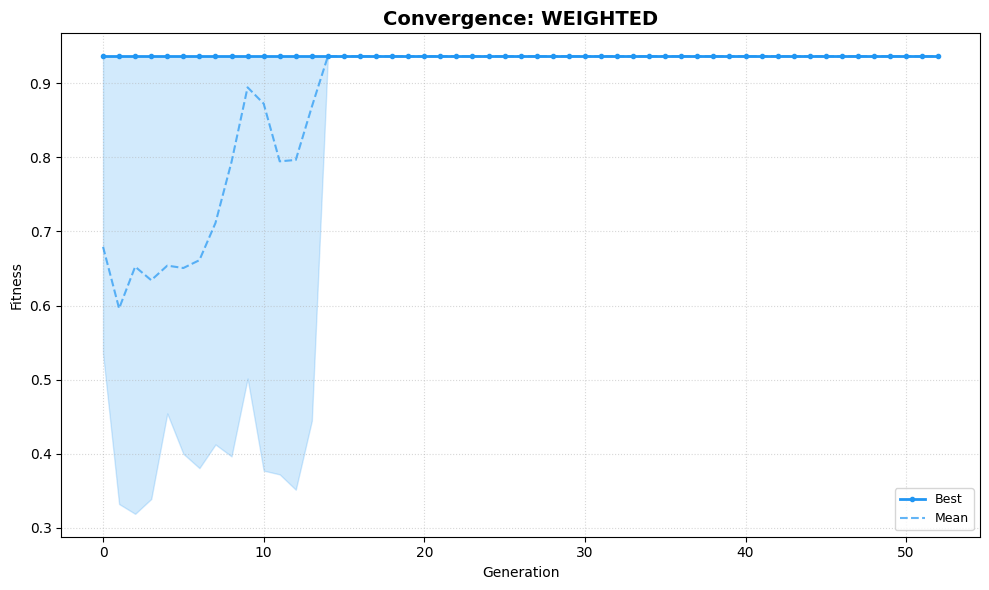

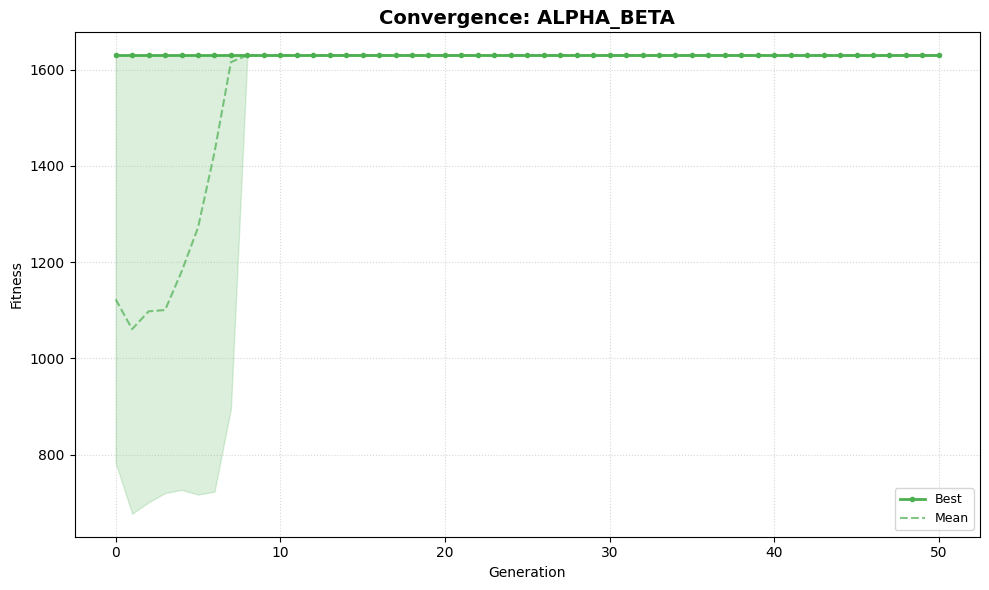

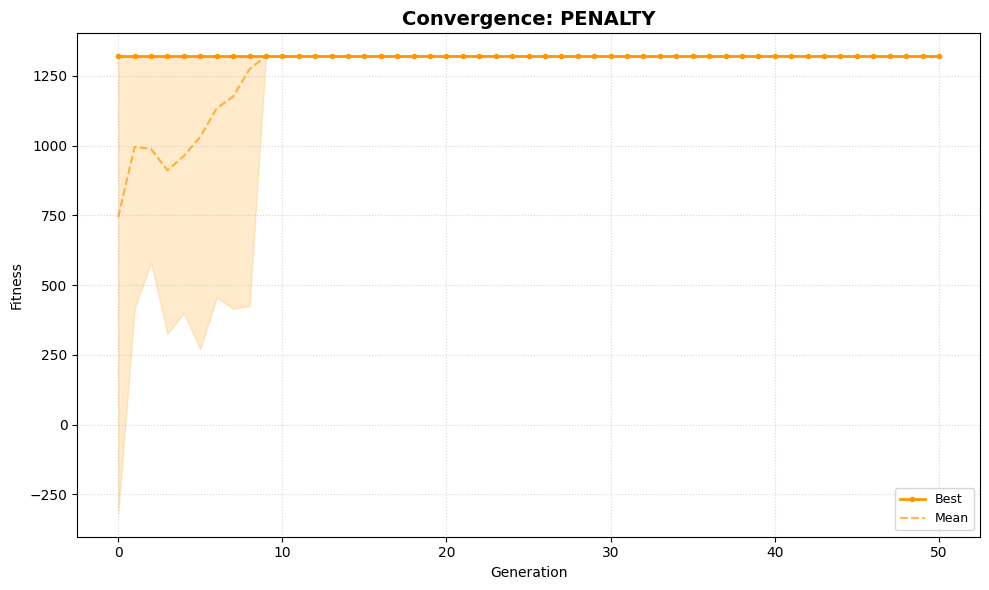

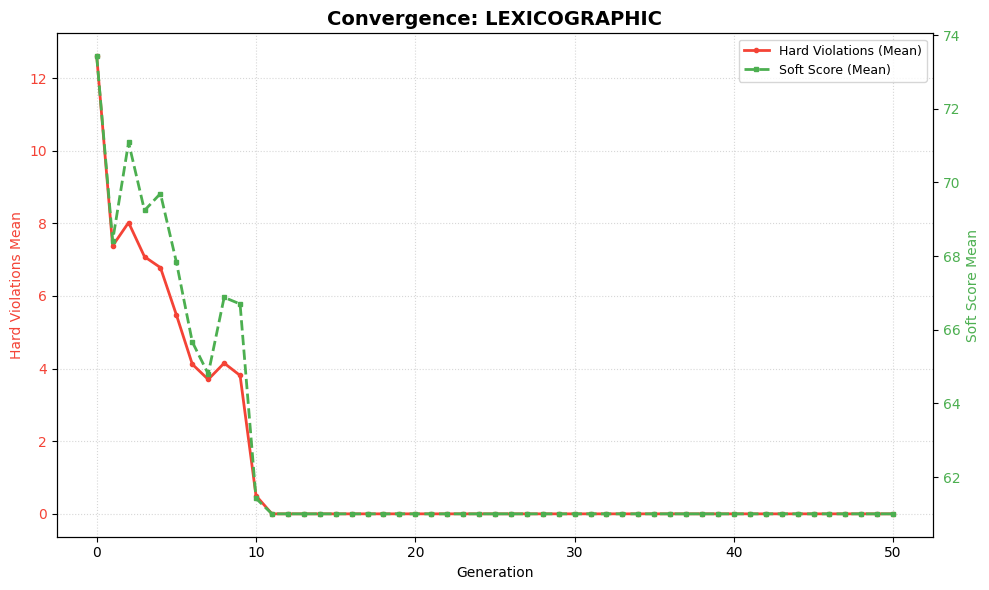

In [8]:
plot_convergence_comparison(results, save_dir="plots")

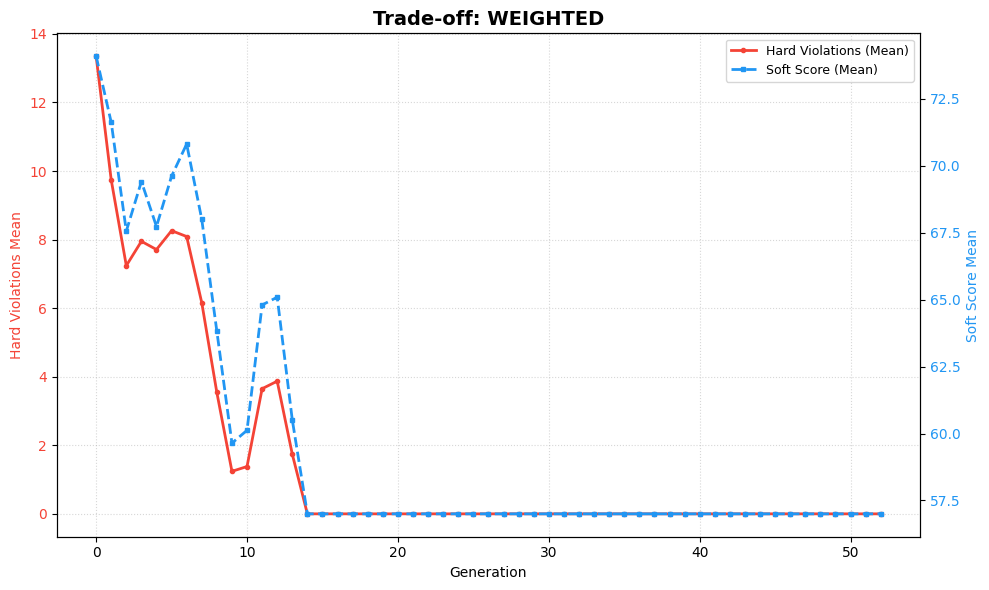

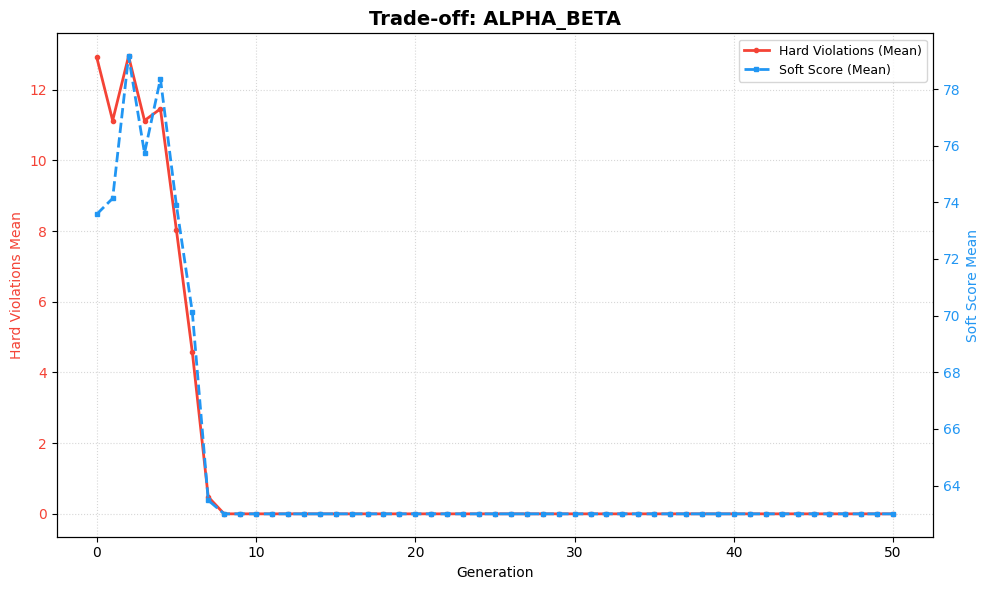

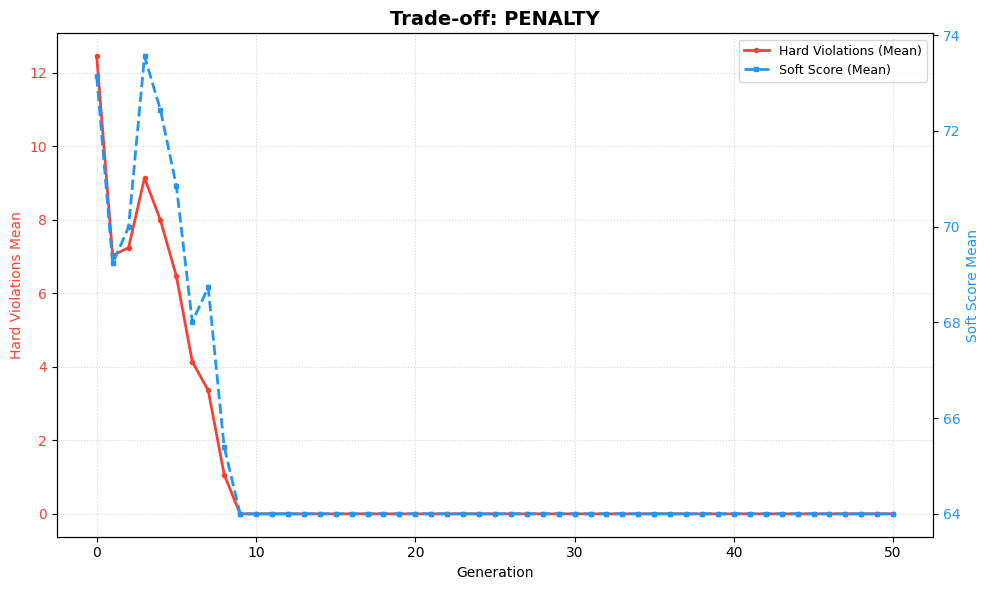

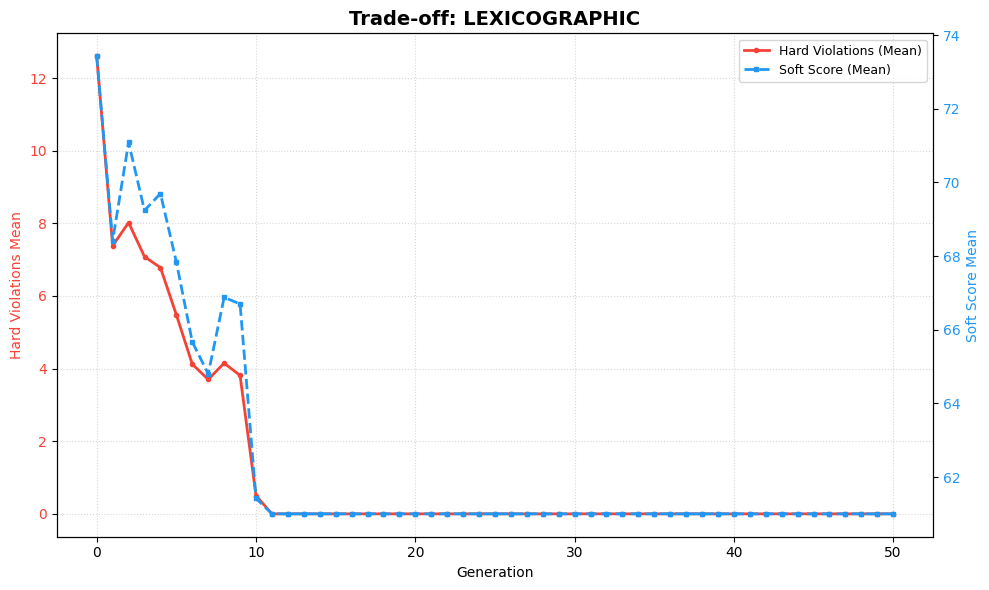

In [9]:
plot_tradeoff_analysis(results, save_dir="plots")

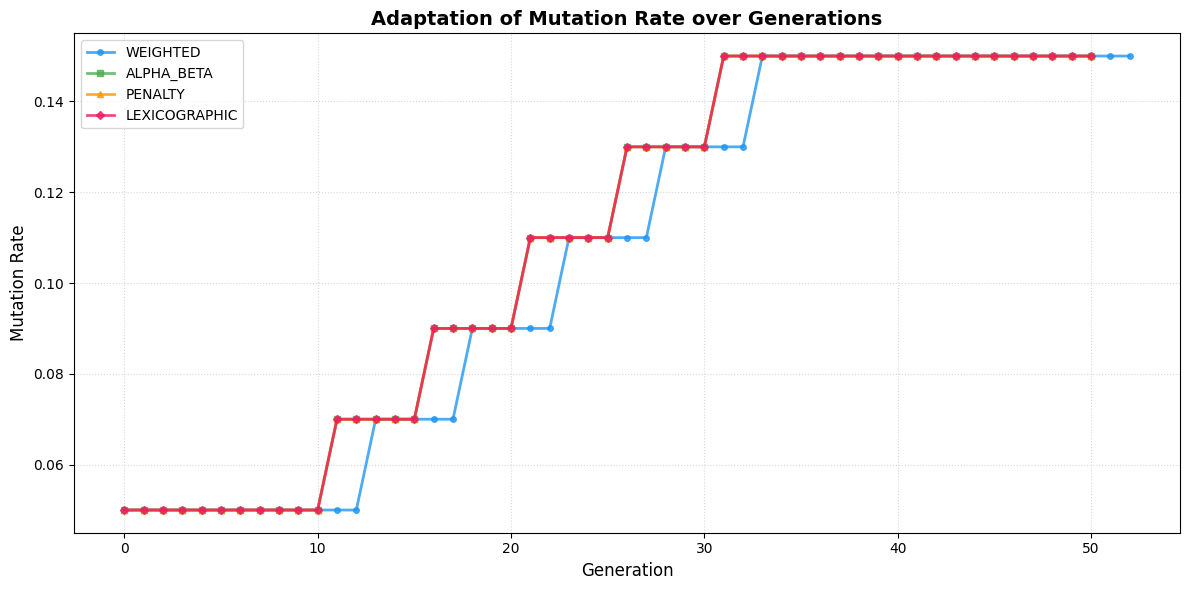

In [10]:
plot_mutation_adaptation(results, save_path="plots/mutation_adaptation.png")

In [11]:
generate_comparison_table(results)


EFFICIENT TABLE BETWEEN ALL FITNESS METHODS
Phuong phap     Generations  Hard Viol.   Soft Score   Best Fitness   
--------------------------------------------------------------------------------
WEIGHTED        53           0            57           0.9366         
ALPHA_BETA      51           0            63           1630.0000      
PENALTY         51           0            64           1320.0000      
LEXICOGRAPHIC   51           0            61           61.0000        


## So sánh các Mutation Methods với Weighted Fitness

Chạy thí nghiệm với các phương pháp mutation khác nhau để so sánh hiệu suất.

In [12]:
def run_mutation_comparison(
    max_generations: int = 200,
    population_size: int = 100,
    seed: Optional[int] = 42,
) -> List[ExperimentResult]:
    """
    Chạy các thí nghiệm với các mutation methods khác nhau sử dụng weighted fitness.

    Args:
        max_generations: Số thế hệ tối đa
        population_size: Kích thước quần thể
        seed: Seed cho random để reproducibility

    Returns:
        Danh sách các ExperimentResult
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    data_store.init()

    mutation_methods = ["random", "swap", "creep", "heuristic"]
    results: List[ExperimentResult] = []

    for method in mutation_methods:
        print(f"\n{'='*60}")
        print(f"Running mutation comparison: {method.upper()}")
        print(f"{'='*60}")

        req = ScheduleRequest()
        req.fitness.method = "weighted"
        req.mutation.method = method
        req.ga.pop_size = population_size
        req.ga.max_generations = max_generations

        scheduler = TrackedGAScheduler(req)
        result = scheduler.run_tracked()

        print(f"\n  Result: {method.upper()}")
        print(f"    - Hard violations: {result.hard_violations}")
        print(f"    - Soft score: {result.soft_score}")
        print(f"    - Generations: {result.generations_run}")
        print(f"    - Stop reason: {result.stop_reason}")
        results.append(result)

    return results

In [13]:
mutation_results = run_mutation_comparison(
    max_generations=200,
    population_size=100,
    seed=42,
)


Running mutation comparison: RANDOM

  Result: RANDOM
    - Hard violations: 0
    - Soft score: 57
    - Generations: 51
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running mutation comparison: SWAP

  Result: SWAP
    - Hard violations: 0
    - Soft score: 53
    - Generations: 162
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running mutation comparison: CREEP

  Result: CREEP
    - Hard violations: 0
    - Soft score: 63
    - Generations: 75
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.

Running mutation comparison: HEURISTIC

  Result: HEURISTIC
    - Hard violations: 0
    - Soft score: 62
    - Generations: 51
    - Stop reason: Quần thể đã bão hoà, không có sự cải thiện sau 20 thế hệ dù đã tối đa tỷ lệ đột biến.


In [14]:
def plot_fitness_over_generation_mutations_improved(
    results: List[ExperimentResult], save_dir: Optional[str] = None
) -> None:
    """
    Vẽ biểu đồ so sánh fitness over generation với thiết kế đẹp hơn.
    """
    import matplotlib.pyplot as plt
    from matplotlib import cm
    
    os.makedirs(save_dir, exist_ok=True) if save_dir else None
    
    # Color palette - sử dụng matplotlib's tab10
    colors = {
        "random": cm.tab10(0),
        "swap": cm.tab10(1),
        "creep": cm.tab10(2),
        "heuristic": cm.tab10(3)
    }
    markers = {
        "random": "o",
        "swap": "s",
        "creep": "^",
        "heuristic": "D"
    }
    linestyles = ['-', '--', '-.', ':']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    ax1, ax2 = axes[0]
    ax3, ax4 = axes[1]
    
    final_results = {}
    
    for idx, result in enumerate(results):
        method = result.method
        hist = result.history
        generations = hist["generations"]
        best_fitness = hist["best_fitness"]
        avg_fitness = hist["avg_fitness"]
        
        color = colors.get(method, cm.tab10(idx))
        marker = markers.get(method, "o")
        linestyle = linestyles[idx % len(linestyles)]
        
        final_best = best_fitness[-1]
        final_avg = avg_fitness[-1]
        final_results[method] = {
            "best": final_best,
            "avg": final_avg,
            "generations": len(generations),
            "color": color
        }
        
        # Best Fitness
        ax1.plot(generations, best_fitness, label=method.upper(),
                color=color, linewidth=2.5, marker=marker, markersize=4, markevery=max(1, len(generations)//10))
        
        # Average Fitness
        ax2.plot(generations, avg_fitness, label=method.upper(),
                color=color, linewidth=2.5, marker=marker, markersize=4, markevery=max(1, len(generations)//10), linestyle='--')
        
        # Hard Violations
        ax3.plot(generations, hist["avg_hard_violations"], label=method.upper(),
                color=color, linewidth=2, marker=marker, markersize=3, markevery=max(1, len(generations)//10))
        
        # Soft Score
        ax4.plot(generations, hist["avg_soft_score"], label=method.upper(),
                color=color, linewidth=2, marker=marker, markersize=3, markevery=max(1, len(generations)//10))
    
    # Style subplots
    for ax, title, ylabel in [
        (ax1, "Best Fitness Over Generations", "Fitness Score"),
        (ax2, "Average Fitness Over Generations", "Fitness Score"),
        (ax3, "Average Hard Violations", "Violations"),
        (ax4, "Average Soft Score", "Score")
    ]:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel("Generation", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(loc='best', fontsize=9, framealpha=0.9)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add summary box
    best_method = max(final_results.keys(), key=lambda x: final_results[x]["best"])
    fastest_method = min(final_results.keys(), key=lambda x: final_results[x]["generations"])
    
    summary_text = (
        f"Best Final Fitness: {best_method.upper()} = {final_results[best_method]['best']:.4f} | ",
        f"Fastest: {fastest_method.upper()} ({final_results[fastest_method]['generations']} gens)"
    )
    
    fig.text(0.5, 0.02, summary_text, ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='gray', alpha=0.8))
    
    plt.suptitle("Genetic Algorithm: Mutation Methods Comparison (Weighted Fitness)",
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if save_dir:
        plt.savefig(f"{save_dir}/fitness_by_mutation_improved.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

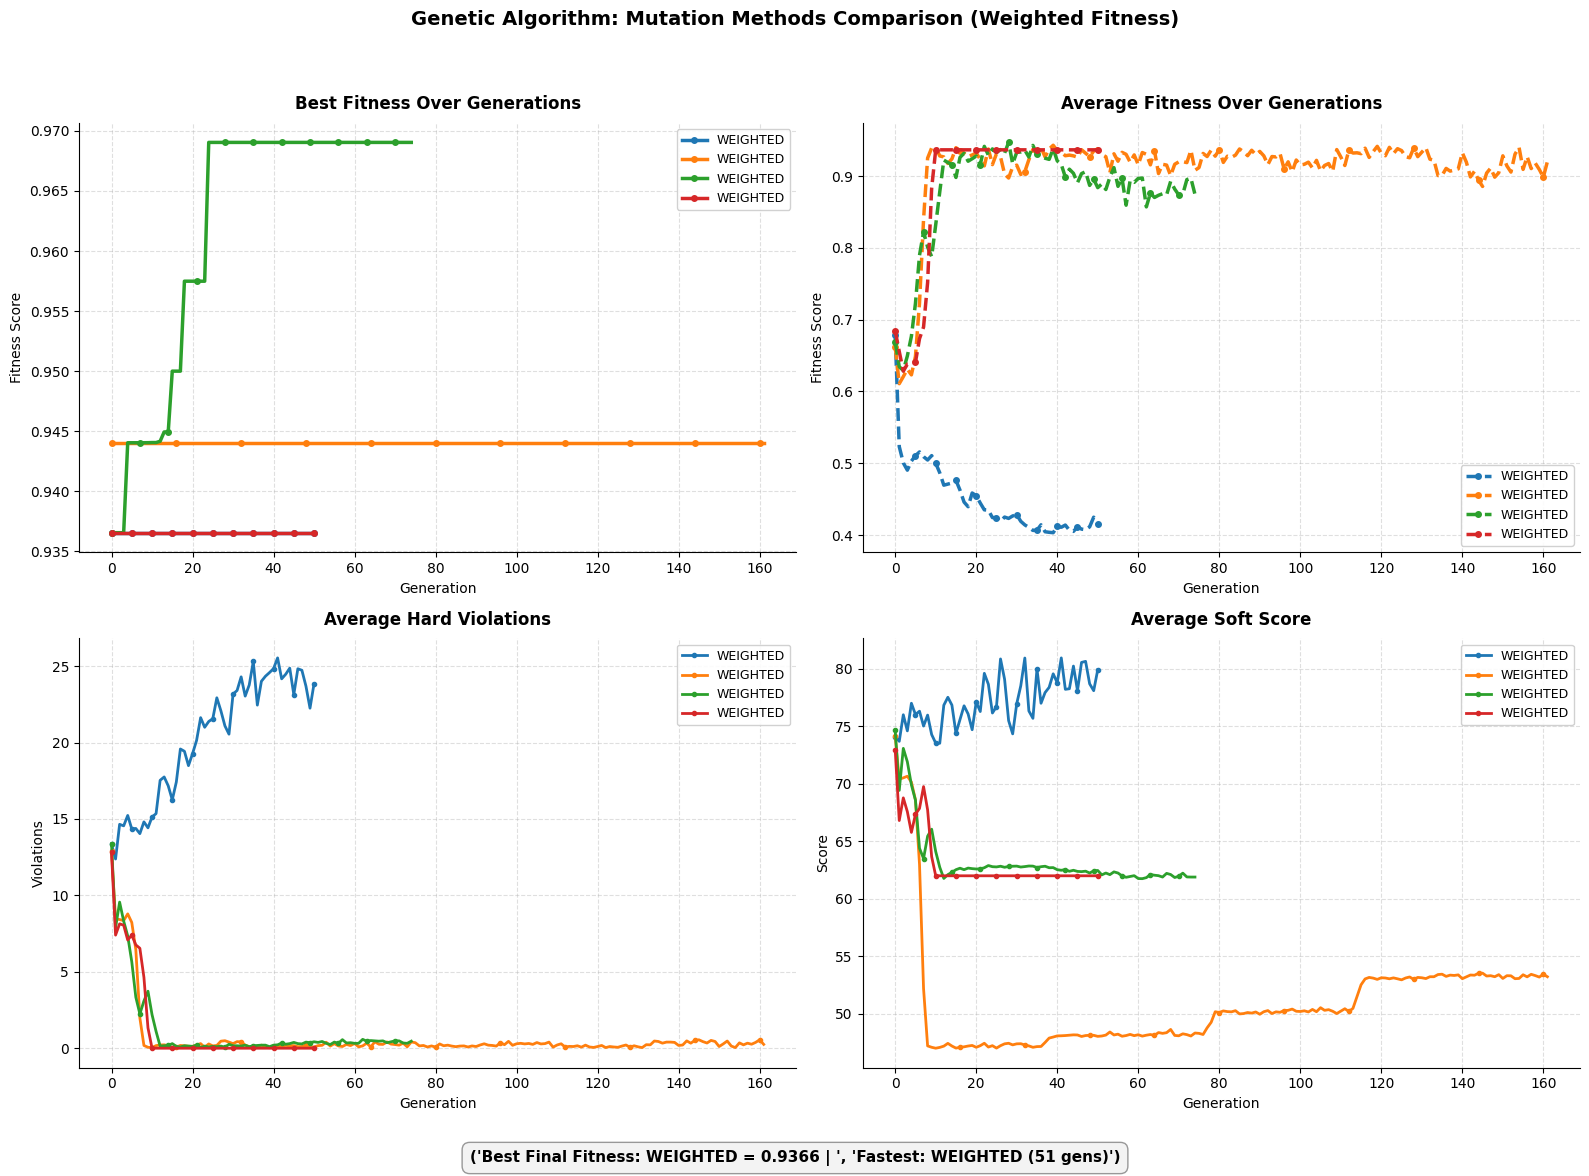

In [15]:
plot_fitness_over_generation_mutations_improved(mutation_results, save_dir="plots")

In [16]:
def generate_mutation_comparison_table(results: List[ExperimentResult]) -> None:
    print("\n" + "=" * 80)
    print("COMPARISON TABLE: MUTATION METHODS (Weighted Fitness)")
    print("=" * 80)
    print(f"{'Mutation Method':<15} {'Generations':<12} {'Hard Viol.':<12} {'Soft Score':<12} {'Best Fitness':<15}")
    print("-" * 80)

    for result in results:
        best_fit = (
            f"{result.history['best_fitness'][-1]:.4f}"
            if result.history.get("best_fitness")
            else "N/A"
        )
        print(
            f"{result.method.upper():<15} "
            f"{result.generations_run:<12} "
            f"{result.hard_violations:<12} "
            f"{result.soft_score:<12} "
            f"{best_fit:<15}"
        )

    print("=" * 80)

generate_mutation_comparison_table(mutation_results)


COMPARISON TABLE: MUTATION METHODS (Weighted Fitness)
Mutation Method Generations  Hard Viol.   Soft Score   Best Fitness   
--------------------------------------------------------------------------------
WEIGHTED        51           0            57           0.9366         
WEIGHTED        162          0            53           0.9440         
WEIGHTED        75           0            63           0.9690         
WEIGHTED        51           0            62           0.9366         


## Đo thời gian chạy các Mutation Methods

In [17]:
import time
from collections import defaultdict

def run_mutation_comparison_timed(
    max_generations: int = 200,
    population_size: int = 100,
    seed: Optional[int] = 42,
) -> Dict[str, float]:
    """
    Chạy các mutation methods và đo thời gian chạy.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    data_store.init()
    
    mutation_methods = ["random", "swap", "creep", "heuristic"]
    timing_results = {}
    
    for method in mutation_methods:
        print(f"Running {method.upper()}...", end=" ")
        start_time = time.time()
        
        req = ScheduleRequest()
        req.fitness.method = "weighted"
        req.mutation.method = method
        req.ga.pop_size = population_size
        req.ga.max_generations = max_generations
        
        scheduler = TrackedGAScheduler(req)
        result = scheduler.run_tracked()
        
        elapsed_time = time.time() - start_time
        timing_results[method] = elapsed_time
        print(f"{elapsed_time:.2f}s")
    
    return timing_results

In [18]:
timing_results = run_mutation_comparison_timed(
    max_generations=200,
    population_size=100,
    seed=42,
)

Running RANDOM... 1.94s
Running SWAP... 5.15s
Running CREEP... 2.66s
Running HEURISTIC... 1.59s


In [19]:
def plot_timing_comparison(timing_results: Dict[str, float], save_dir: Optional[str] = None) -> None:
    """
    Vẽ bar chart so sánh thời gian chạy các mutation methods.
    """
    os.makedirs(save_dir, exist_ok=True) if save_dir else None
    
    methods = list(timing_results.keys())
    times = list(timing_results.values())
    colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(methods, times, color=colors, edgecolor='black', linewidth=1.2)
    
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax.annotate(f'{time_val:.2f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Mutation Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Execution Time Comparison: Mutation Methods\n(Weighted Fitness)', 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    fastest = min(timing_results, key=timing_results.get)
    ax.annotate(f'Fastest: {fastest.upper()}',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/timing_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print("\n" + "=" * 50)
    print("TIMING RESULTS")
    print("=" * 50)
    print(f"{'Method':<15} {'Time (s)':<15} {'Relative':<15}")
    print("-" * 50)
    min_time = min(timing_results.values())
    for method, t in timing_results.items():
        relative = t / min_time
        print(f"{method.upper():<15} {t:<15.2f} {relative:<15.2f}x")
    print("=" * 50)

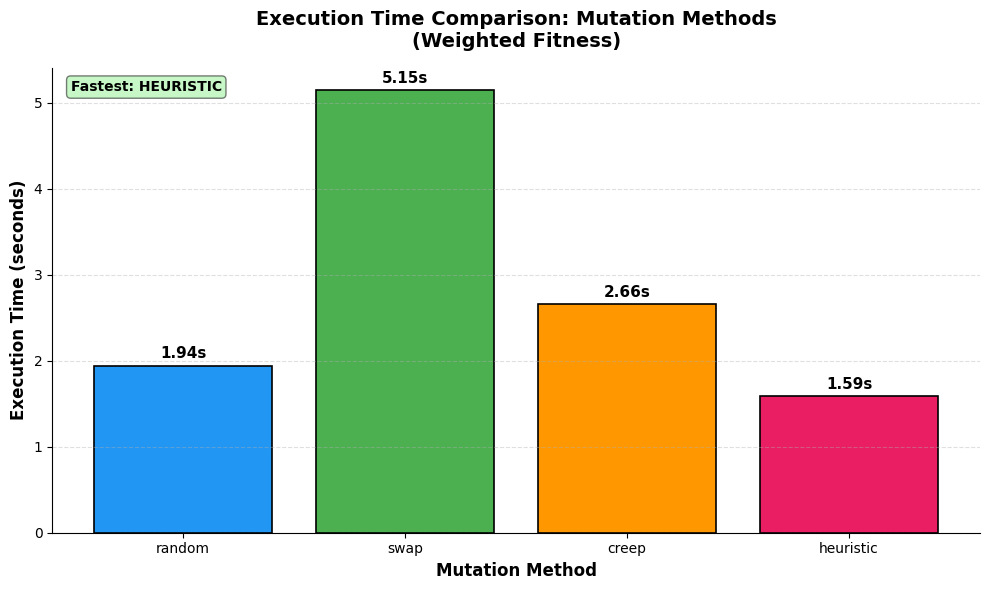


TIMING RESULTS
Method          Time (s)        Relative       
--------------------------------------------------
RANDOM          1.94            1.22           x
SWAP            5.15            3.24           x
CREEP           2.66            1.67           x
HEURISTIC       1.59            1.00           x


In [20]:
plot_timing_comparison(timing_results, save_dir="plots")